# Início: Preparação dos dados

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import random as rd
import os
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import SimpleImputer
from scipy import stats

In [3]:
%matplotlib inline

# @grellert: removendo warnings chatos
import sys

if not sys.warnoptions:
    import warnings
    warnings.simplefilter("ignore")


In [4]:
import os
import pandas as pd
import numpy as np

path = os.path.join('..','dados','brutos','INMET','INMET_FLORIANOPOLIS.CSV')

# 1) tenta encodings comuns do INMET
for enc in ("latin1", "cp1252"):
    try:
        df = pd.read_csv(
            path,
            sep=";",
            encoding=enc,
            engine="python",
            skiprows=8,                 # pula REGIAO/UF/ESTACAO/... (ajuste se necessário)
            decimal=",",                # vírgula decimal brasileira
        )
        print(f"Lido com encoding={enc} | shape={df.shape}")
        break
    except UnicodeDecodeError:
        df = None

if df is None:
    raise UnicodeDecodeError("Não consegui ler com latin1/cp1252. Tente outro encoding ou inspecione o arquivo.")

# 2) limpa nomes de colunas (remove espaços extras)
df.columns = [c.strip() for c in df.columns]

# 3) cria datetime (Data + Hora UTC) se existir
# exemplos: "2025/01/01" + "0000 UTC"
if "Data" in df.columns and "Hora UTC" in df.columns:
    hora = df["Hora UTC"].astype(str).str.extract(r"(\d{4})")[0]
    df["datetime_utc"] = pd.to_datetime(df["Data"].astype(str) + " " + hora, format="%Y/%m/%d %H%M", errors="coerce")

df.head()


Lido com encoding=latin1 | shape=(8760, 20)


,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),...,TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",Unnamed: 19,datetime_utc
0,2025/01/01,0000 UTC,0.0,1013.3,1013.3,1013.0,NaN,25.3,21.1,25.3,...,21.1,20.3,78.0,75.0,78.0,10.0,7.4,2.0,NaN,2025-01-01 00:00:00
1,2025/01/01,0100 UTC,0.0,1013.6,1013.6,1013.1,NaN,24.9,20.9,25.3,...,21.2,20.9,79.0,78.0,78.0,42.0,4.8,1.8,NaN,2025-01-01 01:00:00
2,2025/01/01,0200 UTC,0.0,1014.1,1014.3,1013.6,NaN,24.9,21.0,25.0,...,21.0,20.9,79.0,78.0,79.0,16.0,4.9,1.3,NaN,2025-01-01 02:00:00
3,2025/01/01,0300 UTC,8.2,1013.6,1014.1,1013.6,NaN,24.4,21.7,25.0,...,21.8,20.9,86.0,79.0,85.0,6.0,6.0,0.7,NaN,2025-01-01 03:00:00
4,2025/01/01,0400 UTC,1.0,1012.6,1013.6,1012.6,1.4,24.3,21.4,24.4,...,21.8,21.2,85.0,83.0,84.0,45.0,4.8,1.8,NaN,2025-01-01 04:00:00


In [5]:
df

,Data,Hora UTC,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),...,TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",Unnamed: 19,datetime_utc
0,2025/01/01,0000 UTC,0.0,1013.3,1013.3,1013.0,NaN,25.3,21.1,25.3,...,21.1,20.3,78.0,75.0,78.0,10.0,7.4,2.0,NaN,2025-01-01 00:00:00
1,2025/01/01,0100 UTC,0.0,1013.6,1013.6,1013.1,NaN,24.9,20.9,25.3,...,21.2,20.9,79.0,78.0,78.0,42.0,4.8,1.8,NaN,2025-01-01 01:00:00
2,2025/01/01,0200 UTC,0.0,1014.1,1014.3,1013.6,NaN,24.9,21.0,25.0,...,21.0,20.9,79.0,78.0,79.0,16.0,4.9,1.3,NaN,2025-01-01 02:00:00
3,2025/01/01,0300 UTC,8.2,1013.6,1014.1,1013.6,NaN,24.4,21.7,25.0,...,21.8,20.9,86.0,79.0,85.0,6.0,6.0,0.7,NaN,2025-01-01 03:00:00
4,2025/01/01,0400 UTC,1.0,1012.6,1013.6,1012.6,1.4,24.3,21.4,24.4,...,21.8,21.2,85.0,83.0,84.0,45.0,4.8,1.8,NaN,2025-01-01 04:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2025/12/31,1900 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-31 19:00:00
8756,2025/12/31,2000 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-31 20:00:00
8757,2025/12/31,2100 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-31 21:00:00
8758,2025/12/31,2200 UTC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-12-31 22:00:00


In [7]:
for col in df.columns:
    print(f"{col}: {df[col].dtype}")

Data: object
Hora UTC: object
PRECIPITAÇÃO TOTAL, HORÁRIO (mm): float64
PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB): float64
PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB): float64
PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB): float64
RADIACAO GLOBAL (Kj/m²): float64
TEMPERATURA DO AR - BULBO SECO, HORARIA (°C): float64
TEMPERATURA DO PONTO DE ORVALHO (°C): float64
TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C): float64
TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C): float64
TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C): float64
TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C): float64
UMIDADE REL. MAX. NA HORA ANT. (AUT) (%): float64
UMIDADE REL. MIN. NA HORA ANT. (AUT) (%): float64
UMIDADE RELATIVA DO AR, HORARIA (%): float64
VENTO, DIREÇÃO HORARIA (gr) (° (gr)): float64
VENTO, RAJADA MAXIMA (m/s): float64
VENTO, VELOCIDADE HORARIA (m/s): float64
datetime_utc: datetime64[ns]


In [6]:
df = df.dropna(axis=1, how='all')


In [8]:
np.where(pd.isnull(df))

(array([   0,    1,    2, ..., 8759, 8759, 8759], shape=(94982,)),
 array([ 6,  6,  6, ..., 16, 17, 18], shape=(94982,)))

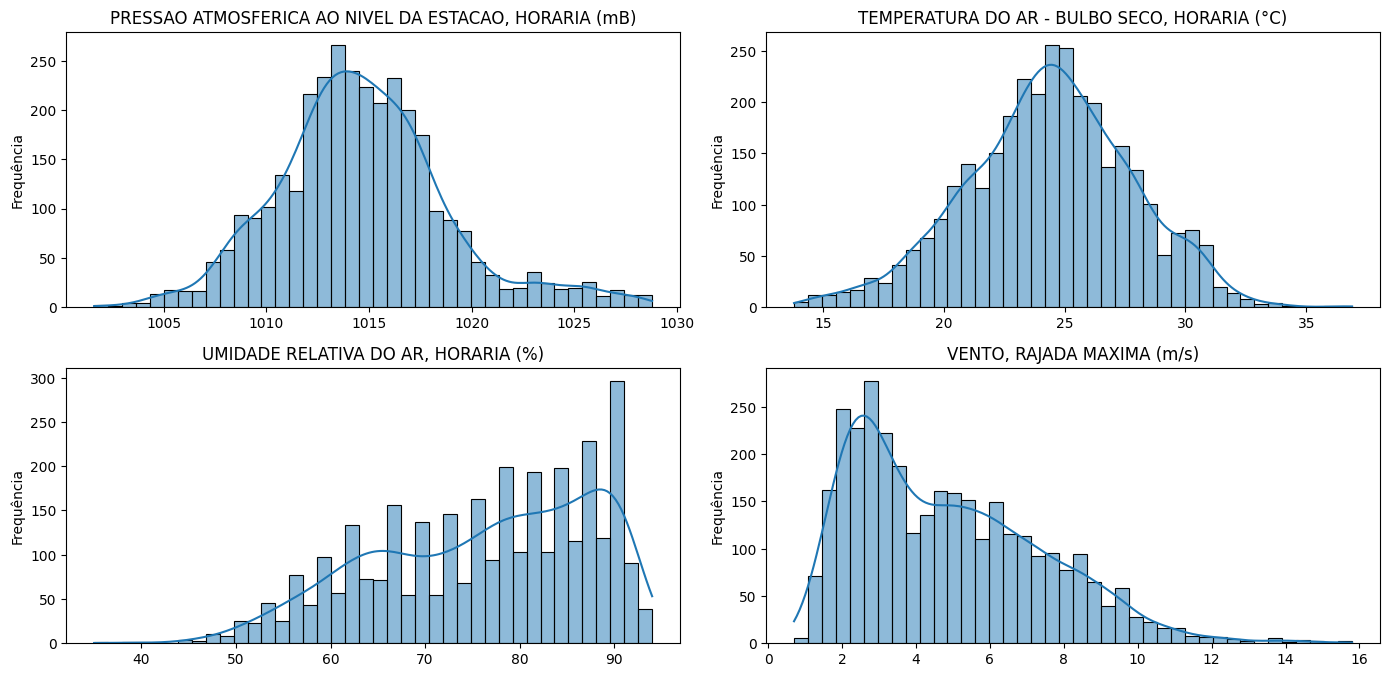

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

selected_cols = [
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)',
    'VENTO, RAJADA MAXIMA (m/s)',
]

plt.figure(figsize=(14, 10))

for i, col in enumerate(selected_cols, 1):
    plt.subplot(3, 2, i)
    sns.histplot(df[col], bins=40, kde=True)
    plt.title(col)
    plt.xlabel("")
    plt.ylabel("Frequência")

plt.tight_layout()
plt.show()



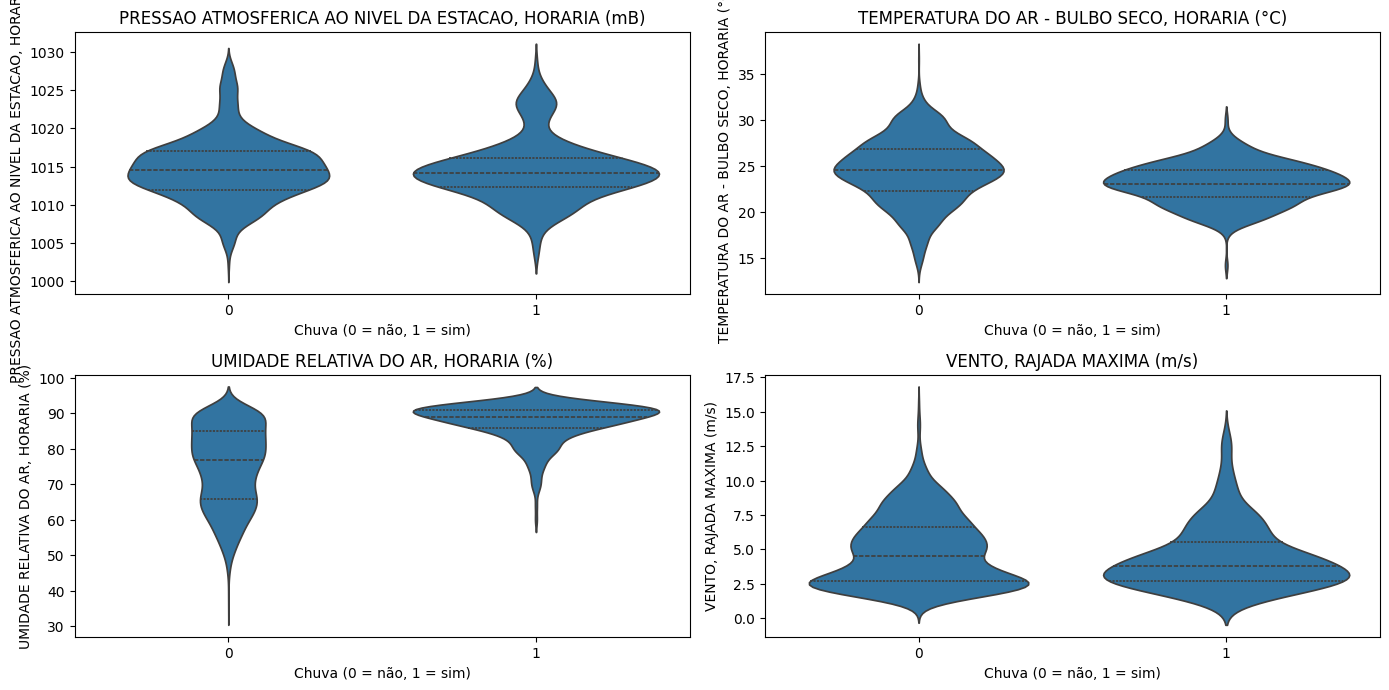

In [10]:
df['chuva'] = np.where(
    df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] > 0,
    1,
    0
)

plt.figure(figsize=(14, 10))

for i, col in enumerate(selected_cols, 1):
    plt.subplot(3, 2, i)
    sns.violinplot(
        data=df,
        x='chuva',
        y=col,
        inner='quartile'
    )
    plt.title(col)
    plt.xlabel("Chuva (0 = não, 1 = sim)")

plt.tight_layout()
plt.show()


In [10]:
# =========================================================
# PREPARO DOS DADOS
# =========================================================

df = df.copy()

df["chuva"] = np.where(df[target_col] > 0, 1, 0).astype("int64")

mask = df[target_col].notna()

X_full = df.loc[mask, selected_cols].copy()
y_full = df.loc[mask, "chuva"].copy()

print("Distribuição da variável alvo:")
print(y_full.value_counts(normalize=True).sort_index())

Distribuição da variável alvo:
chuva
0    0.901166
1    0.098834
Name: proportion, dtype: float64


In [82]:
df.describe()

,"PRECIPITAÇÃO TOTAL, HORÁRIO (mm)","PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)",PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB),PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB),RADIACAO GLOBAL (Kj/m²),"TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)",TEMPERATURA DO PONTO DE ORVALHO (°C),TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C),TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C),TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C),UMIDADE REL. MAX. NA HORA ANT. (AUT) (%),UMIDADE REL. MIN. NA HORA ANT. (AUT) (%),"UMIDADE RELATIVA DO AR, HORARIA (%)","VENTO, DIREÇÃO HORARIA (gr) (° (gr))","VENTO, RAJADA MAXIMA (m/s)","VENTO, VELOCIDADE HORARIA (m/s)",datetime_utc,chuva
count,3258.000000,3258.000000,3258.000000,3258.000000,1810.000000,3258.000000,3258.000000,3258.000000,3258.000000,3258.000000,3258.000000,3258.000000,3258.000000,3258.000000,3258.000000,3258.000000,3258.000000,8760,8760.000000
mean,0.249847,1014.667434,1014.905003,1014.424125,1359.740387,24.365378,19.695457,24.775660,23.982627,20.121271,19.280049,78.288828,73.989257,76.206568,187.749847,4.834254,1.673051,2025-07-02 11:30:00,0.036758
min,0.000000,1001.600000,1002.200000,1001.600000,0.000000,13.800000,7.600000,14.100000,13.700000,8.500000,7.600000,40.000000,32.000000,35.000000,1.000000,0.700000,0.000000,2025-01-01 00:00:00,0.000000
25%,0.000000,1012.100000,1012.300000,1011.800000,274.300000,22.200000,17.900000,22.600000,21.800000,18.300000,17.400000,70.000000,64.000000,67.000000,119.000000,2.700000,0.700000,2025-04-02 05:45:00,0.000000
50%,0.000000,1014.400000,1014.700000,1014.200000,1113.650000,24.500000,20.300000,24.800000,24.100000,20.700000,19.800000,80.000000,76.000000,78.000000,167.000000,4.400000,1.500000,2025-07-02 11:30:00,0.000000
75%,0.000000,1016.900000,1017.100000,1016.700000,2350.225000,26.600000,22.000000,27.100000,26.200000,22.300000,21.600000,87.000000,84.000000,86.000000,288.000000,6.600000,2.500000,2025-10-01 17:15:00,0.000000
max,42.600000,1028.800000,1028.900000,1028.600000,3942.400000,36.900000,25.400000,38.000000,36.100000,25.600000,25.300000,94.000000,93.000000,94.000000,360.000000,15.800000,6.600000,2025-12-31 23:00:00,1.000000
std,1.692446,4.201908,4.179462,4.217342,1151.448172,3.435689,2.965198,3.491633,3.376371,2.907910,3.024964,10.523848,12.259033,11.461218,111.483398,2.551734,1.174731,NaN,0.188178


In [36]:
TH_CATEGORICO = 5
categoricos = [] 
string = []
quantitativos = []
nao_numericos = []

for col in df:
    print(col, df[col].unique())
    unicos = df[col].unique()
    ## dividindo colunas entre valores categoricos e quantitativos:
    if unicos.shape[0] < TH_CATEGORICO:
        categoricos.append(col)
    else: 
        quantitativos.append(col)
print(f'colunas categoricas: {len(categoricos)}, quantitativas: {len(quantitativos)}')

Data ['2025/01/01' '2025/01/02' '2025/01/03' '2025/01/04' '2025/01/05'
 '2025/01/06' '2025/01/07' '2025/01/08' '2025/01/09' '2025/01/10'
 '2025/01/11' '2025/01/12' '2025/01/13' '2025/01/14' '2025/01/15'
 '2025/01/16' '2025/01/17' '2025/01/18' '2025/01/19' '2025/01/20'
 '2025/01/21' '2025/01/22' '2025/01/23' '2025/01/24' '2025/01/25'
 '2025/01/26' '2025/01/27' '2025/01/28' '2025/01/29' '2025/01/30'
 '2025/01/31' '2025/02/01' '2025/02/02' '2025/02/03' '2025/02/04'
 '2025/02/05' '2025/02/06' '2025/02/07' '2025/02/08' '2025/02/09'
 '2025/02/10' '2025/02/11' '2025/02/12' '2025/02/13' '2025/02/14'
 '2025/02/15' '2025/02/16' '2025/02/17' '2025/02/18' '2025/02/19'
 '2025/02/20' '2025/02/21' '2025/02/22' '2025/02/23' '2025/02/24'
 '2025/02/25' '2025/02/26' '2025/02/27' '2025/02/28' '2025/03/01'
 '2025/03/02' '2025/03/03' '2025/03/04' '2025/03/05' '2025/03/06'
 '2025/03/07' '2025/03/08' '2025/03/09' '2025/03/10' '2025/03/11'
 '2025/03/12' '2025/03/13' '2025/03/14' '2025/03/15' '2025/03/16'
 '202

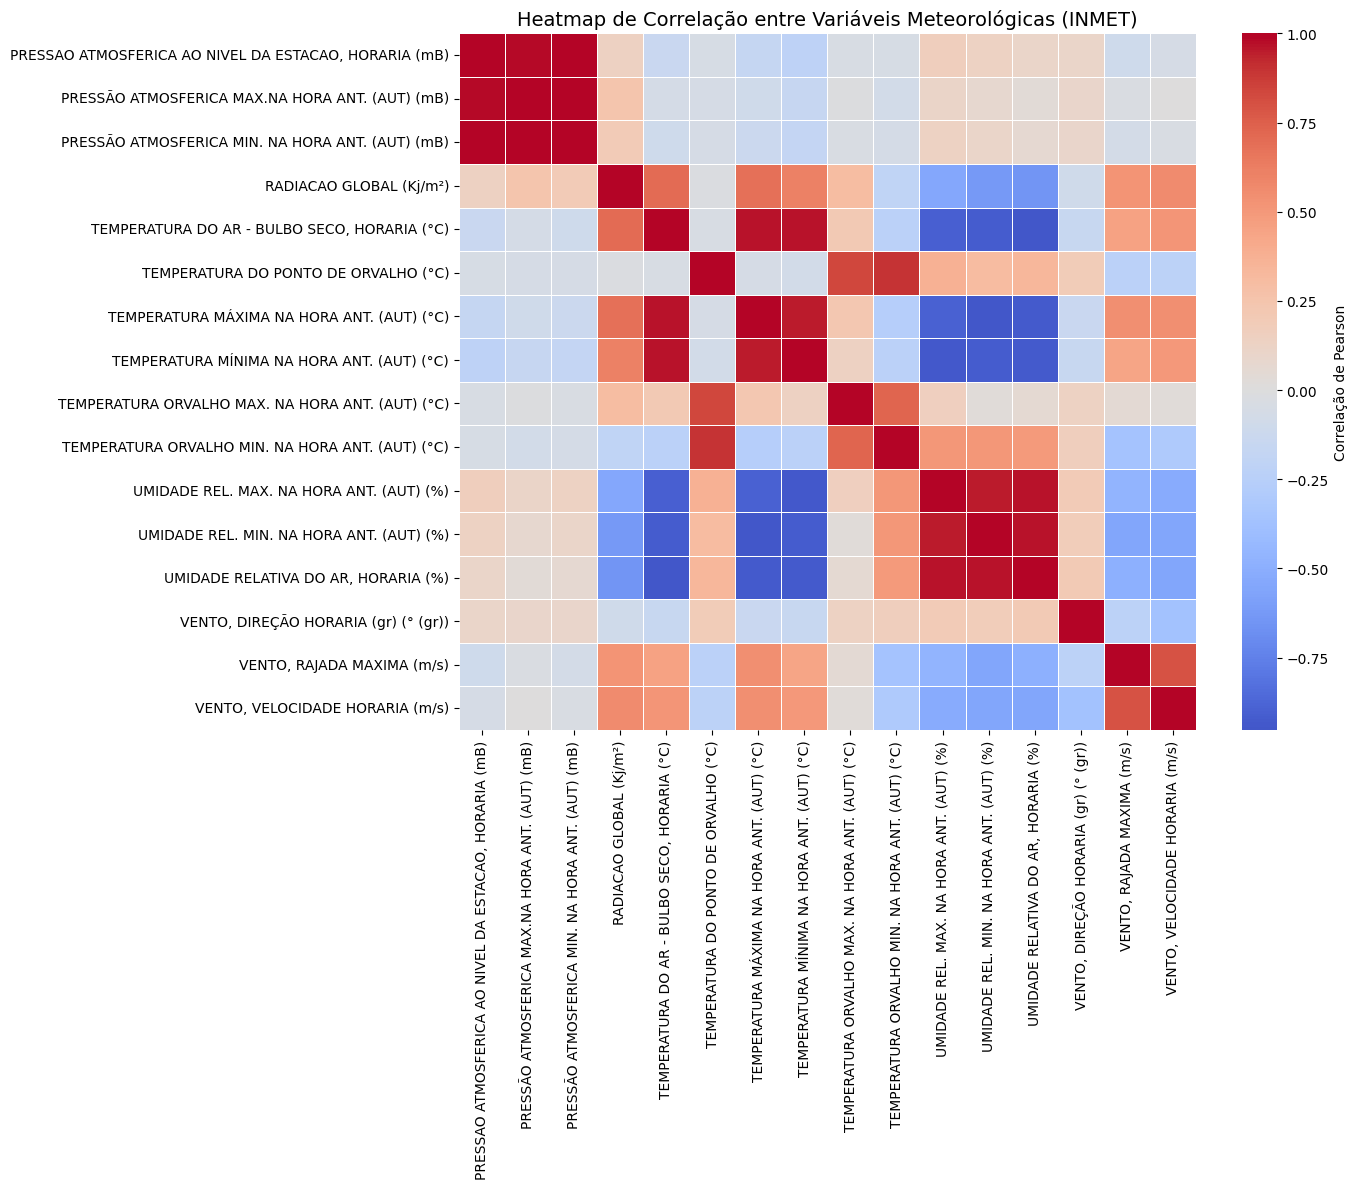

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1) Criação do desfecho (CLASSIFICAÇÃO)
# =========================
# 0 = não choveu | 1 = choveu
df['chuva'] = np.where(
    df['PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'] > 0,
    1,
    0
)

# =========================
# 2) Seleção das variáveis numéricas (exclui o alvo)
# =========================
num_cols = [
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
    'PRESSÃO ATMOSFERICA MAX.NA HORA ANT. (AUT) (mB)',
    'PRESSÃO ATMOSFERICA MIN. NA HORA ANT. (AUT) (mB)',
    'RADIACAO GLOBAL (Kj/m²)',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
    'TEMPERATURA DO PONTO DE ORVALHO (°C)',
    'TEMPERATURA MÁXIMA NA HORA ANT. (AUT) (°C)',
    'TEMPERATURA MÍNIMA NA HORA ANT. (AUT) (°C)',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT) (°C)',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT) (°C)',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT) (%)',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT) (%)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)',
    'VENTO, DIREÇÃO HORARIA (gr) (° (gr))',
    'VENTO, RAJADA MAXIMA (m/s)',
    'VENTO, VELOCIDADE HORARIA (m/s)'
]

df_num = df[num_cols].copy()

# =========================
# 3) Matriz de correlação
# =========================
corr = df_num.corr(method='pearson')

# =========================
# 4) Heatmap
# =========================
plt.figure(figsize=(14, 12))
sns.heatmap(
    corr,
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Correlação de Pearson'}
)

plt.title('Heatmap de Correlação entre Variáveis Meteorológicas (INMET)', fontsize=14)
plt.tight_layout()
plt.show()


# Análise I - Estatística

## Gerador de Dados Faltantes - MAR, MNAR e MCAR

Distribuição da variável alvo — INMET diário:
chuva
0    0.485294
1    0.514706
Name: proportion, dtype: float64

Tamanho da base diária:
Amostras: 136 dias

Iniciando coleta de distribuições...
Total de cenários: 1600
--------------------------------------------------

 Atributo atual: PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)
   % faltante: 5%
      Progresso: 10/1600 (0.6%) | Tempo decorrido: 0.0 min | ETA: 4.1 min
      Progresso: 20/1600 (1.2%) | Tempo decorrido: 0.1 min | ETA: 4.1 min
      Progresso: 30/1600 (1.9%) | Tempo decorrido: 0.1 min | ETA: 4.1 min
      Progresso: 40/1600 (2.5%) | Tempo decorrido: 0.1 min | ETA: 4.1 min
      Progresso: 50/1600 (3.1%) | Tempo decorrido: 0.1 min | ETA: 4.0 min
      Progresso: 60/1600 (3.8%) | Tempo decorrido: 0.2 min | ETA: 4.0 min
      Progresso: 70/1600 (4.4%) | Tempo decorrido: 0.2 min | ETA: 3.9 min
      Progresso: 80/1600 (5.0%) | Tempo decorrido: 0.2 min | ETA: 3.9 min
      Progresso: 90/1600 (5.6%) | Tempo decorrid

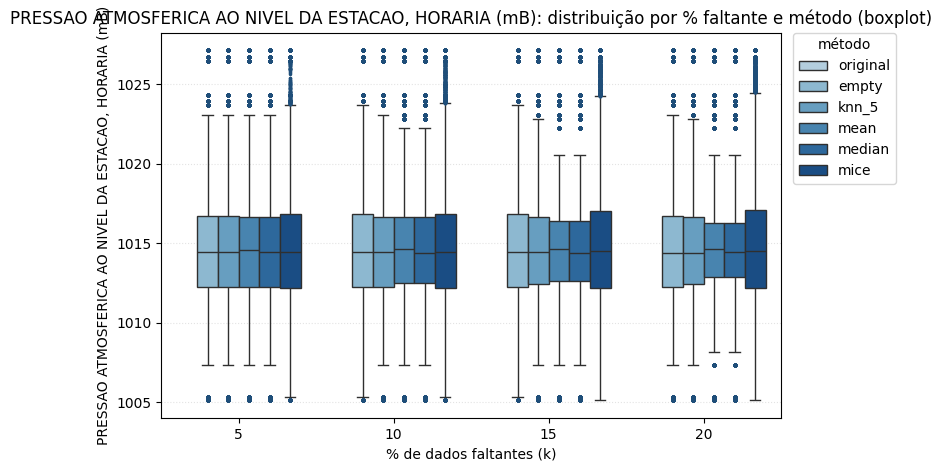

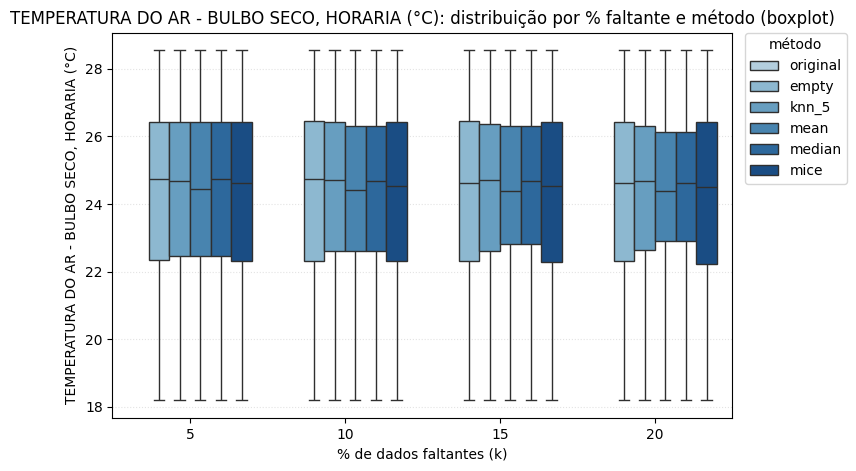

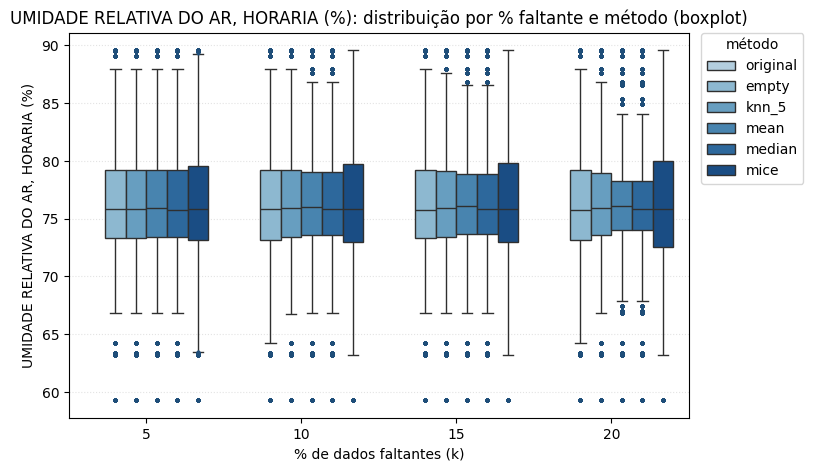

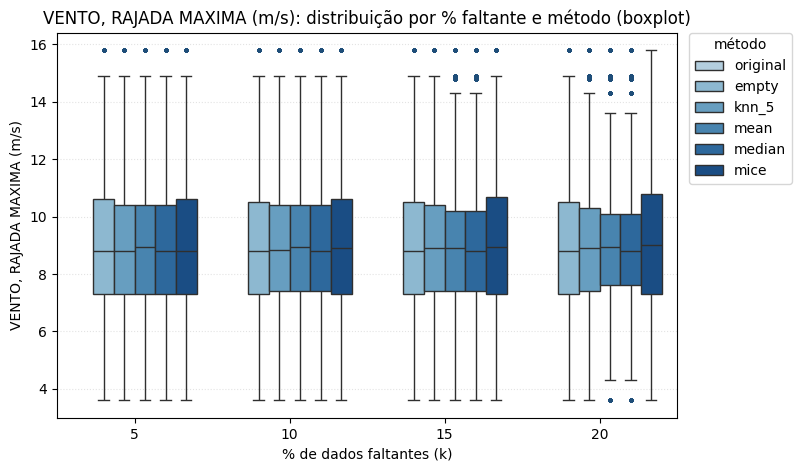

In [11]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import BayesianRidge

# ---------------------------------------------------------
# Helpers: aplicar uma imputação sobre um X_nan JÁ mascarado
# ---------------------------------------------------------
def _apply_imputation(X_nan: pd.DataFrame, method: str, seed: int | None = None) -> pd.DataFrame:
    """Aplica imputação no DataFrame X_nan (com NaNs já aplicados).
       Retorna um DataFrame imputado (todas as colunas numéricas)."""
    if method == "mean":
        Xi = X_nan.copy()
        for c in Xi.columns:
            Xi[c] = Xi[c].fillna(Xi[c].mean())
        return Xi

    if method == "median":
        Xi = X_nan.copy()
        for c in Xi.columns:
            Xi[c] = Xi[c].fillna(Xi[c].median())
        return Xi

    if method.startswith("knn_"):
        try:
            n = int(method.split("_", 1)[1])
        except Exception:
            raise ValueError("Use método como 'knn_5', 'knn_7', etc.")
        imp = KNNImputer(n_neighbors=n)
        return pd.DataFrame(imp.fit_transform(X_nan), columns=X_nan.columns, index=X_nan.index)

    if method == "mice":
        col_mins = X_nan.quantile(0.01, numeric_only=True).reindex(X_nan.columns).to_numpy()
        col_maxs = X_nan.quantile(0.99, numeric_only=True).reindex(X_nan.columns).to_numpy()
        Xnum = X_nan.to_numpy(dtype=float)
        col_mins = np.where(np.isfinite(col_mins), col_mins, np.nanmin(Xnum, axis=0))
        col_maxs = np.where(np.isfinite(col_maxs), col_maxs, np.nanmax(Xnum, axis=0))

        imp = IterativeImputer(
            max_iter=20,
            imputation_order="ascending",
            initial_strategy="median",
            skip_complete=True,
            sample_posterior=False,
            min_value=col_mins,
            max_value=col_maxs,
            random_state=seed,
        )
        return pd.DataFrame(imp.fit_transform(X_nan), columns=X_nan.columns, index=X_nan.index)
    
    # if method == "missforest":
    #     est = RandomForestRegressor(
    #         n_estimators=200,
    #         random_state=seed,
    #         n_jobs=-1
    #     )
    #     imp = IterativeImputer(
    #         estimator=est,
    #         max_iter=10,
    #         initial_strategy="median",
    #         skip_complete=True,
    #         random_state=seed
    #     )
    #     return pd.DataFrame(imp.fit_transform(X_nan), columns=X_nan.columns, index=X_nan.index)

    if method == "empty":
        return X_nan.copy()

    raise ValueError(f"Método inválido: {method}")

def _apply_mice_mi(
    X_nan: pd.DataFrame,
    seed: int | None = None,
    m: int = 5
) -> list[pd.DataFrame]:
    """
    Aplica MICE como imputação múltipla.
    Retorna uma lista com m DataFrames imputados.
    """

    col_mins = X_nan.quantile(0.01, numeric_only=True).reindex(X_nan.columns).to_numpy()
    col_maxs = X_nan.quantile(0.99, numeric_only=True).reindex(X_nan.columns).to_numpy()

    Xnum = X_nan.to_numpy(dtype=float)

    col_mins = np.where(
        np.isfinite(col_mins),
        col_mins,
        np.nanmin(Xnum, axis=0)
    )

    col_maxs = np.where(
        np.isfinite(col_maxs),
        col_maxs,
        np.nanmax(Xnum, axis=0)
    )

    imputed_datasets = []

    for i in range(m):
        imp = IterativeImputer(
            estimator=BayesianRidge(),
            max_iter=20,
            imputation_order="ascending",
            initial_strategy="median",
            skip_complete=True,
            sample_posterior=True,
            min_value=col_mins,
            max_value=col_maxs,
            random_state=None if seed is None else seed + i
        )

        Xi = pd.DataFrame(
            imp.fit_transform(X_nan),
            columns=X_nan.columns,
            index=X_nan.index
        )

        imputed_datasets.append(Xi)

    return imputed_datasets

# ---------------------------------------------------------
# Coletar "dados brutos" (valores) para plotar as distribuições
# ---------------------------------------------------------
import time

def collect_raw_distributions(
    X: pd.DataFrame,
    y: pd.Series,
    columns: list[str],
    methods: list[str],
    ks=(5, 10, 15, 20),
    reps=10,
    missing_mech="MCAR",
    seed_base=2025,
    sample_per_cell: int | None = 2000,
    pick_missing_indices=None,
    verbose=True
):
    assert pick_missing_indices is not None, "Passe sua função pick_missing_indices."
    rows = []

    total_steps = len(columns) * len(ks) * reps
    step = 0
    t0 = time.time()

    if verbose:
        print(f"\nIniciando coleta de distribuições...")
        print(f"Total de cenários: {total_steps}")
        print("-" * 50)

    for col in columns:
        if verbose:
            print(f"\n Atributo atual: {col}")

        v_orig_full = X[col].to_numpy()

        for k in ks:
            if verbose:
                print(f"   % faltante: {k}%")

            for r in range(reps):
                step += 1
                seed = seed_base + 1000 * k + r
                rng = np.random.default_rng(seed)

                X_nan = X.copy(deep=True)
                to_nan = pick_missing_indices(missing_mech, X_nan, y, col, k, seed=seed)
                if len(to_nan) > 0:
                    X_nan.loc[to_nan, col] = np.nan

                # ORIGINAL
                v_orig = v_orig_full
                if sample_per_cell is not None and len(v_orig) > sample_per_cell:
                    v_orig = rng.choice(v_orig, size=sample_per_cell, replace=False)
                rows.extend((col, k, "original", r, float(v)) for v in v_orig if np.isfinite(v))

                # MÉTODOS
                for method in methods:
                    if method == "mice":
                        imputed_datasets = _apply_mice_mi(
                            X_nan,
                            seed=seed,
                            m=5
                        )

                        for imp_id, Xi in enumerate(imputed_datasets, start=1):
                            v_vals = Xi[col].to_numpy()

                            if sample_per_cell is not None and len(v_vals) > sample_per_cell:
                                v_vals = rng.choice(v_vals, size=sample_per_cell, replace=False)

                            rows.extend(
                                (col, k, method, r, imp_id, float(v))
                                for v in v_vals
                                if np.isfinite(v)
                            )

                    else:
                        Xi = _apply_imputation(X_nan, method, seed=seed)

                        if method == "empty":
                            v_vals = Xi[col].dropna().to_numpy()
                        else:
                            v_vals = Xi[col].to_numpy()

                        if sample_per_cell is not None and len(v_vals) > sample_per_cell:
                            v_vals = rng.choice(v_vals, size=sample_per_cell, replace=False)

                        rows.extend(
                            (col, k, method, r, 1, float(v))
                            for v in v_vals
                            if np.isfinite(v)
                        )

                # -------- PROGRESSO --------
                if verbose and (step % 10 == 0 or step == total_steps):
                    elapsed = time.time() - t0
                    progress = step / total_steps
                    eta = (elapsed / step) * (total_steps - step)

                    print(
                        f"      Progresso: {step}/{total_steps} "
                        f"({progress*100:.1f}%) | "
                        f"Tempo decorrido: {elapsed/60:.1f} min | "
                        f"ETA: {eta/60:.1f} min",
                        flush=True
                    )

    if verbose:
        total_time = time.time() - t0
        print("\n Finalizado!")
        print(f"Tempo total: {total_time/60:.2f} minutos")

    return pd.DataFrame(
        rows,
        columns=["attribute", "pct_imputed", "method", "rep", "imputation", "value"]
    )

# ---------------------------------------------------------
# Plots: BOX – x = % faltante, hue = método
# ---------------------------------------------------------
def plot_box_all_methods_one_axis(
    df_long: pd.DataFrame,
    attribute: str,
    order_pct: list[int] = (5, 10, 15, 20),
    showfliers: bool = False,
    height: float = 5.0,
    aspect: float = 1.6,
    legend_out: bool = True,
):
    dfp = df_long[df_long["attribute"] == attribute].copy()

    dfp["pct_imputed"] = pd.Categorical(
        dfp["pct_imputed"],
        categories=order_pct,
        ordered=True
    )

    base = ["original"]
    outros = sorted([m for m in dfp["method"].unique() if m not in base])
    order_methods = base + outros

    dfp["method"] = pd.Categorical(
        dfp["method"],
        categories=order_methods,
        ordered=True
    )

    # Paleta em tons de azul
    palette = sns.color_palette(
        "Blues",
        n_colors=len(order_methods) + 2
    )[2:]

    plt.figure(figsize=(height * aspect, height))

    ax = sns.boxplot(
        data=dfp,
        x="pct_imputed",
        y="value",
        hue="method",
        order=order_pct,
        hue_order=order_methods,
        palette=palette,
        showfliers=showfliers,
        flierprops={
            "marker": ".",
            "markersize": 3,
            "linestyle": "none",
            "markerfacecolor": "#1f4e79",
            "markeredgecolor": "#1f4e79"
        }
    )

    ax.set_xlabel("% de dados faltantes (k)")
    ax.set_ylabel(attribute)
    ax.set_title(f"{attribute}: distribuição por % faltante e método (boxplot)")

    if legend_out:
        ax.legend(
            title="método",
            bbox_to_anchor=(1.02, 1),
            loc="upper left",
            borderaxespad=0
        )
    else:
        ax.legend(title="método")

    ax.grid(axis="y", linestyle=":", alpha=0.35)

    return ax

# ---------------------------------------------------------
# USO com INMET: base diária + desfecho chuva diária
# ---------------------------------------------------------
# 0) garanta que df já existe e que as colunas abaixo estão com esses nomes

target_col = 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'

selected_cols = [
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)',
    'VENTO, RAJADA MAXIMA (m/s)'
]

# 1) Garante formato de data
df = df.copy()
df["data"] = pd.to_datetime(df["Data"], errors="coerce")
df = df[df["data"].notna()].copy()

# 2) Garante formato numérico nas colunas usadas
for col in selected_cols + [target_col]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# 3) Agregação diária
df_diario = (
    df
    .groupby(df["data"].dt.floor("D"))
    .agg({
        target_col: "sum",
        'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': "mean",
        'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': "mean",
        'UMIDADE RELATIVA DO AR, HORARIA (%)': "mean",
        'VENTO, RAJADA MAXIMA (m/s)': "max"
    })
    .reset_index()
)

# 4) Desfecho diário: 1 = choveu no dia, 0 = não choveu no dia
df_diario["chuva"] = (df_diario[target_col] > 0).astype("int64")

# 5) Mantém apenas linhas válidas para atributos e alvo
mask_valid = df_diario[selected_cols + [target_col]].notna().all(axis=1)

X = df_diario.loc[mask_valid, selected_cols].copy()
y = df_diario.loc[mask_valid, "chuva"].copy()

print("Distribuição da variável alvo — INMET diário:")
print(y.value_counts(normalize=True).sort_index())

print("\nTamanho da base diária:")
print(f"Amostras: {len(X)} dias")

# 6) Função de mascaramento MCAR
def pick_missing_indices(missing_mech, X, y, col, k, seed=None):
    rng = np.random.default_rng(seed)
    candidates = X.index[X[col].notna()].to_numpy()
    m = int(round(len(candidates) * (k / 100.0)))
    m = min(m, len(candidates))
    return rng.choice(candidates, size=m, replace=False) if m > 0 else []

# 7) Rodar coleta e plotar
methods = ["empty", "mean", "median", "knn_5", "mice"]
ks = (5, 10, 15, 20)
reps = 100

df_long = collect_raw_distributions(
    X, y,
    columns=selected_cols,
    methods=methods,
    ks=ks,
    reps=reps,
    missing_mech="MCAR",
    seed_base=2025,
    sample_per_cell=2000,
    pick_missing_indices=pick_missing_indices,
    verbose=True
)

for attr in selected_cols:
    ax = plot_box_all_methods_one_axis(
        df_long,
        attr,
        order_pct=list(ks),
        showfliers=True
    )
    plt.show()


# Análise II — Machine Learning

Distribuição da variável alvo (DIÁRIO, >0 mm):
chuva
0    0.485294
1    0.514706
Name: proportion, dtype: float64

Tamanho da base:
Amostras: 136
[1/4000] 0.0% k=5% rep=1/100 method=empty model=logreg ETA=0.1min
[2/4000] 0.1% k=5% rep=1/100 method=empty model=tree_overfit ETA=74.5min
[3/4000] 0.1% k=5% rep=1/100 method=mean model=logreg ETA=79.7min
[4/4000] 0.1% k=5% rep=1/100 method=mean model=tree_overfit ETA=80.6min
[5/4000] 0.1% k=5% rep=1/100 method=median model=logreg ETA=81.8min
[6/4000] 0.1% k=5% rep=1/100 method=median model=tree_overfit ETA=68.6min
[7/4000] 0.2% k=5% rep=1/100 method=knn_5 model=logreg ETA=59.3min
[8/4000] 0.2% k=5% rep=1/100 method=knn_5 model=tree_overfit ETA=52.2min
[9/4000] 0.2% k=5% rep=1/100 method=mice model=logreg ETA=46.8min
[10/4000] 0.2% k=5% rep=1/100 method=mice model=tree_overfit ETA=50.9min
[11/4000] 0.3% k=5% rep=2/100 method=empty model=logreg ETA=53.0min
[12/4000] 0.3% k=5% rep=2/100 method=empty model=tree_overfit ETA=48.8min
[13/4000] 0.3%

,pct_missing,method,model,f1,recall,precision,accuracy
0,0,original_dropna,logreg,0.6709,0.6571,0.6938,0.6693
1,0,original_dropna,tree_overfit,0.6023,0.6143,0.5952,0.5939
2,5,empty,logreg,0.6524,0.6296,0.6997,0.6620
3,5,empty,tree_overfit,0.6303,0.6254,0.6560,0.6308
4,5,knn_5,logreg,0.6551,0.6307,0.6982,0.6646
5,5,knn_5,tree_overfit,0.6307,0.6270,0.6489,0.6297
6,5,mean,logreg,0.6549,0.6314,0.6958,0.6637
7,5,mean,tree_overfit,0.6332,0.6254,0.6578,0.6351
8,5,median,logreg,0.6533,0.6266,0.6991,0.6646
9,5,median,tree_overfit,0.6294,0.6219,0.6528,0.6310


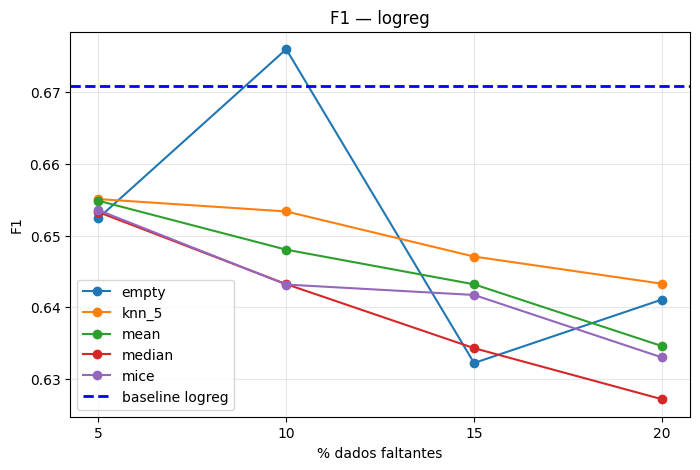

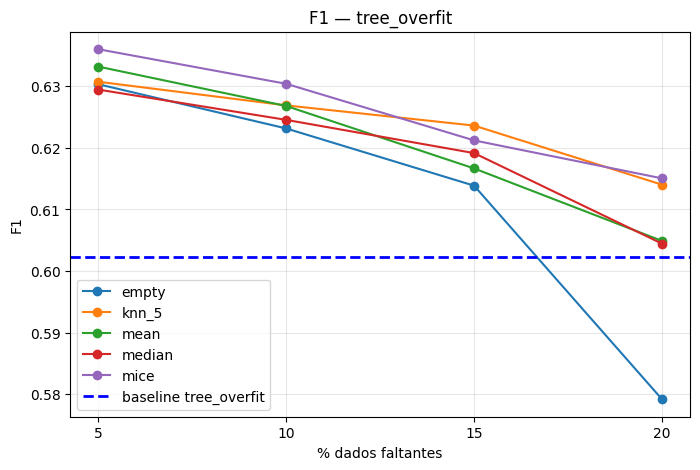

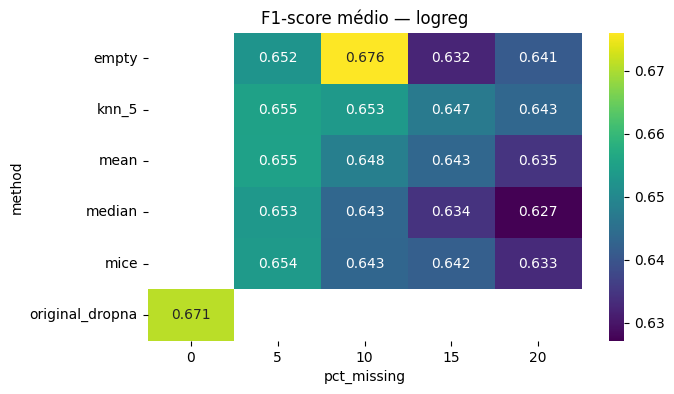

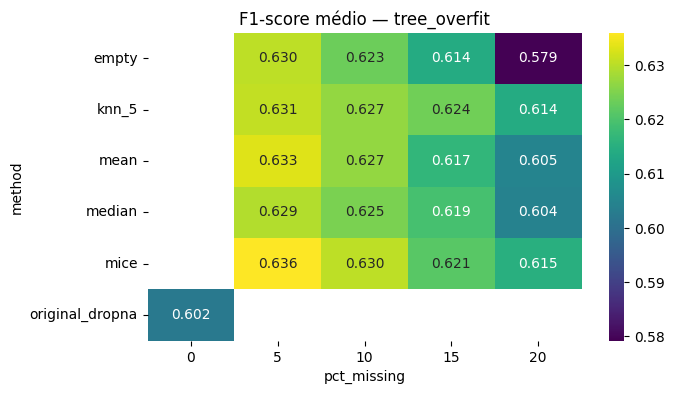

In [30]:
# =========================================================
# FASE 2 — ML (Regressão Logística + Árvore de Decisão Sobreajustada) + BASELINE ORIGINAL
# BASE DIÁRIA (> 0 mm)
# imputação feita dentro do fold (sem leakage)
# MICE ajustado para imputação múltipla (MI)
# =========================================================

import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from joblib import Parallel, delayed

from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, BayesianRidge
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    f1_score, recall_score, precision_score,
    accuracy_score
)

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import IterativeImputer


# =========================================================
# CONFIG
# =========================================================

selected_cols = [
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)',
    'UMIDADE RELATIVA DO AR, HORARIA (%)',
    'VENTO, RAJADA MAXIMA (m/s)'
]

target_col = 'PRECIPITAÇÃO TOTAL, HORÁRIO (mm)'

# MICE aqui é MI de fato: gera múltiplas bases imputadas e combina as probabilidades
methods = ["empty", "mean", "median", "knn_5", "mice"]

# Número de imputações múltiplas para o MICE-MI
mice_m = 5

# Modelos avaliados:
# - logreg: modelo linear regularizado
# - tree_overfit: árvore de decisão praticamente sem poda, útil para observar sobreajuste
models = ["logreg", "tree_overfit"]

ks = (5, 10, 15, 20)
reps = 100
n_splits = 5
seed_base = 2025
n_jobs = -1


# =========================================================
# PREPARO DOS DADOS — BASE DIÁRIA
# =========================================================

df = df.copy()

# garante datetime
df["data"] = pd.to_datetime(df["Data"], errors="coerce")
df = df[df["data"].notna()].copy()

# agregação diária
df_diario = (
    df
    .groupby(df["data"].dt.floor("D"))
    .agg({
        target_col: "sum",
        'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA (mB)': "mean",
        'TEMPERATURA DO AR - BULBO SECO, HORARIA (°C)': "mean",
        'UMIDADE RELATIVA DO AR, HORARIA (%)': "mean",
        'VENTO, RAJADA MAXIMA (m/s)': "max"
    })
    .reset_index()
)

# variável alvo diária (> 0 mm)
df_diario["chuva"] = (df_diario[target_col] > 0).astype("int64")

# mantém apenas linhas válidas
mask = df_diario[selected_cols + [target_col]].notna().all(axis=1)

X_full = df_diario.loc[mask, selected_cols].copy()
y_full = df_diario.loc[mask, "chuva"].copy()

print("Distribuição da variável alvo (DIÁRIO, >0 mm):")
print(y_full.value_counts(normalize=True).sort_index())

print("\nTamanho da base:")
print(f"Amostras: {len(X_full)}")


# =========================================================
# GERAR ÍNDICES MCAR
# =========================================================

def pick_missing_indices(X, col, k, seed):

    rng = np.random.default_rng(seed)

    candidates = X.index[X[col].notna()].to_numpy()

    m = int(round(len(candidates) * (k / 100.0)))

    m = min(m, len(candidates))

    if m == 0:
        return []

    return rng.choice(candidates, size=m, replace=False)


# =========================================================
# LIMITES PARA O ITERATIVE IMPUTER
# =========================================================

def get_train_bounds(Xtr_nan):

    # usa apenas o treino para evitar leakage
    Xnum = Xtr_nan.to_numpy(dtype=float)

    col_mins = Xtr_nan.quantile(0.01, numeric_only=True).reindex(Xtr_nan.columns).to_numpy()
    col_maxs = Xtr_nan.quantile(0.99, numeric_only=True).reindex(Xtr_nan.columns).to_numpy()

    fallback_min = np.nanmin(Xnum, axis=0)
    fallback_max = np.nanmax(Xnum, axis=0)

    col_mins = np.where(np.isfinite(col_mins), col_mins, fallback_min)
    col_maxs = np.where(np.isfinite(col_maxs), col_maxs, fallback_max)

    return col_mins, col_maxs


# =========================================================
# FACTORY DE IMPUTERS SIMPLES
# =========================================================

def make_imputer(method, seed):

    if method == "empty":
        return None

    if method == "mean":
        return SimpleImputer(strategy="mean")

    if method == "median":
        return SimpleImputer(strategy="median")

    if method.startswith("knn_"):
        n = int(method.split("_")[1])
        return KNNImputer(n_neighbors=n)

    # MICE é tratado separadamente porque MI retorna várias imputações,
    # não apenas uma matriz/base imputada.
    if method == "mice":
        return "mice_mi"

    raise ValueError(method)


# =========================================================
# MICE COMO IMPUTAÇÃO MÚLTIPLA
# =========================================================

def make_mice_mi_imputer(Xtr_nan, seed, imputation_id):

    col_mins, col_maxs = get_train_bounds(Xtr_nan)

    return IterativeImputer(
        estimator=BayesianRidge(),
        max_iter=20,
        imputation_order="ascending",
        initial_strategy="median",
        skip_complete=True,
        sample_posterior=True,
        min_value=col_mins,
        max_value=col_maxs,
        random_state=seed + 10000 * imputation_id
    )


# =========================================================
# FACTORY DE CLASSIFICADORES
# =========================================================

def make_classifier(model, seed):

    if model == "logreg":

        clf = LogisticRegression(
            max_iter=2000,
            class_weight="balanced"
        )

        return Pipeline([
            ("scaler", StandardScaler()),
            ("clf", clf)
        ])

    if model == "tree_overfit":

        # Árvore deliberadamente pouco restringida:
        # maior risco de memorizar ruído e padrões específicos do treino.
        clf = DecisionTreeClassifier(
            criterion="gini",
            max_depth=None,
            min_samples_split=2,
            min_samples_leaf=1,
            class_weight="balanced",
            random_state=seed
        )

        return Pipeline([
            ("clf", clf)
        ])

    raise ValueError(model)


# =========================================================
# MÉTRICAS
# =========================================================

def calculate_metrics(y_true, yhat, yscore):

    if len(y_true) < 2 or pd.Series(y_true).nunique() < 2:
        return None

    return (
        f1_score(y_true, yhat, zero_division=0),
        recall_score(y_true, yhat, zero_division=0),
        precision_score(y_true, yhat, zero_division=0),
        accuracy_score(y_true, yhat),
    )


# =========================================================
# AVALIAR UM FOLD — MÉTODOS SIMPLES
# =========================================================

def eval_one_fold_single_imputation(Xtr_nan, Xte_nan, ytr, yte, method, model, seed):

    imp = make_imputer(method, seed)

    if imp is None:

        tr_ok = ~Xtr_nan.isna().any(axis=1)
        te_ok = ~Xte_nan.isna().any(axis=1)

        Xtr = Xtr_nan.loc[tr_ok]
        ytr2 = ytr.loc[tr_ok]

        Xte = Xte_nan.loc[te_ok]
        yte2 = yte.loc[te_ok]

        if len(Xtr) < 10 or len(Xte) < 10 or ytr2.nunique() < 2 or yte2.nunique() < 2:
            return None

    else:

        Xtr = pd.DataFrame(
            imp.fit_transform(Xtr_nan),
            columns=Xtr_nan.columns,
            index=Xtr_nan.index
        )

        Xte = pd.DataFrame(
            imp.transform(Xte_nan),
            columns=Xte_nan.columns,
            index=Xte_nan.index
        )

        ytr2 = ytr
        yte2 = yte

    pipe = make_classifier(model, seed)

    pipe.fit(Xtr, ytr2)

    yhat = pipe.predict(Xte)
    yscore = pipe.predict_proba(Xte)[:, 1]

    return calculate_metrics(yte2, yhat, yscore)


# =========================================================
# AVALIAR UM FOLD — MICE-MI
# =========================================================

def eval_one_fold_mice_mi(Xtr_nan, Xte_nan, ytr, yte, model, seed, m=5):

    if len(Xtr_nan) < 10 or len(Xte_nan) < 10 or ytr.nunique() < 2 or yte.nunique() < 2:
        return None

    probas = []

    for imputation_id in range(m):

        imp = make_mice_mi_imputer(
            Xtr_nan=Xtr_nan,
            seed=seed,
            imputation_id=imputation_id
        )

        Xtr = pd.DataFrame(
            imp.fit_transform(Xtr_nan),
            columns=Xtr_nan.columns,
            index=Xtr_nan.index
        )

        Xte = pd.DataFrame(
            imp.transform(Xte_nan),
            columns=Xte_nan.columns,
            index=Xte_nan.index
        )

        pipe = make_classifier(
            model=model,
            seed=seed + 10000 * imputation_id
        )

        pipe.fit(Xtr, ytr)

        probas.append(pipe.predict_proba(Xte)[:, 1])

    # Combinação das múltiplas imputações:
    # média das probabilidades previstas pelos modelos treinados em cada base imputada.
    yscore = np.mean(probas, axis=0)
    yhat = (yscore >= 0.5).astype(int)

    return calculate_metrics(yte, yhat, yscore)


# =========================================================
# AVALIAR UM FOLD — ROTEADOR
# =========================================================

def eval_one_fold(Xtr_nan, Xte_nan, ytr, yte, method, model, seed):

    if method == "mice":
        return eval_one_fold_mice_mi(
            Xtr_nan=Xtr_nan,
            Xte_nan=Xte_nan,
            ytr=ytr,
            yte=yte,
            model=model,
            seed=seed,
            m=mice_m
        )

    return eval_one_fold_single_imputation(
        Xtr_nan=Xtr_nan,
        Xte_nan=Xte_nan,
        ytr=ytr,
        yte=yte,
        method=method,
        model=model,
        seed=seed
    )


# =========================================================
# BASELINE ORIGINAL
# =========================================================

def run_original_baseline(X, y, seed=2025, n_splits=5):

    ok = ~X.isna().any(axis=1)

    X0 = X.loc[ok]
    y0 = y.loc[ok]

    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=seed
    )

    rows = []

    for model in models:

        f1s, recs, precs, accs = [], [], [], []

        for fold, (tr, te) in enumerate(skf.split(X0, y0), start=1):

            Xtr, Xte = X0.iloc[tr], X0.iloc[te]
            ytr, yte = y0.iloc[tr], y0.iloc[te]

            pipe = make_classifier(model, seed + fold)

            pipe.fit(Xtr, ytr)

            yhat = pipe.predict(Xte)
            yscore = pipe.predict_proba(Xte)[:, 1]

            metrics = calculate_metrics(yte, yhat, yscore)

            if metrics is None:
                continue

            f1, rec, prec, acc = metrics

            f1s.append(f1)
            recs.append(rec)
            precs.append(prec)
            accs.append(acc)

        rows.append({
            "pct_missing": 0,
            "method": "original_dropna",
            "model": model,
            "f1": np.mean(f1s),
            "recall": np.mean(recs),
            "precision": np.mean(precs),
            "accuracy": np.mean(accs),
        })

    return pd.DataFrame(rows)


# =========================================================
# EXPERIMENTO PRINCIPAL
# =========================================================

def run_ml_experiment(X, y):

    rows = []
    total = len(ks) * reps * len(methods) * len(models)
    step = 0
    t0 = time.time()

    for k in ks:

        for r in range(reps):

            seed = seed_base + 1000*k + r

            X_nan = X.copy()

            for j, col in enumerate(X_nan.columns):

                idx_nan = pick_missing_indices(X_nan, col, k, seed+17*j)

                if len(idx_nan) > 0:
                    X_nan.loc[idx_nan, col] = np.nan

            skf = StratifiedKFold(
                n_splits=n_splits,
                shuffle=True,
                random_state=seed
            )

            splits = list(skf.split(X_nan, y))

            for method in methods:

                for model in models:

                    step += 1

                    elapsed = time.time() - t0
                    progress = step / total
                    eta = (elapsed/step) * (total-step)

                    print(
                        f"[{step}/{total}] {progress*100:.1f}% "
                        f"k={k}% rep={r+1}/{reps} method={method} model={model} "
                        f"ETA={eta/60:.1f}min"
                    )

                    fold_results = Parallel(n_jobs=n_jobs)(

                        delayed(eval_one_fold)(
                            X_nan.iloc[tr],
                            X_nan.iloc[te],
                            y.iloc[tr],
                            y.iloc[te],
                            method,
                            model,
                            seed + fold_id
                        )

                        for fold_id, (tr, te) in enumerate(splits, start=1)
                    )

                    fold_results = [x for x in fold_results if x is not None]

                    if not fold_results:
                        continue

                    f1s, recs, precs, accs = map(list, zip(*fold_results))

                    rows.append({
                        "pct_missing": k,
                        "rep": r + 1,
                        "seed": seed,
                        "method": method,
                        "model": model,
                        "f1": np.mean(f1s),
                        "recall": np.mean(recs),
                        "precision": np.mean(precs),
                        "accuracy": np.mean(accs),
                    })
                    
    return pd.DataFrame(rows)


# =========================================================
# RODAR EXPERIMENTO
# =========================================================

baseline = run_original_baseline(X_full, y_full)
results = run_ml_experiment(X_full, y_full)
results_all = pd.concat([baseline, results], ignore_index=True)


# =========================================================
# RESUMO
# =========================================================

metric_cols = ["f1", "recall", "precision", "accuracy"]

summary = (

    results_all
    .groupby(["pct_missing", "method", "model"], as_index=False)[metric_cols]
    .mean()

)

display(summary.round(4))


# =========================================================
# GRÁFICOS
# =========================================================

summary_plot = summary[summary["pct_missing"] > 0]

def plot_metric(metric, model_name):
    plt.figure(figsize=(8,5))

    d_model = summary_plot[summary_plot["model"] == model_name]

    x_vals = sorted(d_model["pct_missing"].unique())

    baseline_value = summary[
        (summary["pct_missing"] == 0) &
        (summary["model"] == model_name)
    ][metric].iloc[0]

    for method in d_model["method"].unique():
        d = d_model[d_model["method"] == method].sort_values("pct_missing")

        plt.plot(
            d["pct_missing"],
            d[metric],
            marker="o",
            label=method
        )

    plt.axhline(
        baseline_value,
        color="blue",
        linestyle="--",
        linewidth=2,
        label=f"baseline {model_name}"
    )

    plt.title(f"{metric.upper()} — {model_name}")
    plt.xlabel("% dados faltantes")
    plt.ylabel(metric.upper())
    plt.xticks(x_vals)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

for model_name in models:
    plot_metric("f1", model_name)

# =========================================================
# HEATMAP
# =========================================================

for model_name in models:

    pivot = (
        summary[summary["model"] == model_name]
        .pivot(index="method", columns="pct_missing", values="f1")
    )

    plt.figure(figsize=(7,4))

    sns.heatmap(pivot, annot=True, cmap="viridis", fmt=".3f")

    plt.title(f"F1-score médio — {model_name}")

    plt.show()


# Análise III - Testes Estatísticos Par a Par

In [27]:
# =========================================================
# FASE 3 — TESTES ESTATÍSTICOS PAR A PAR
# Wilcoxon pareado + correção Holm-Bonferroni
# =========================================================

from itertools import combinations

import numpy as np
import pandas as pd

from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests


# =========================================================
# FUNÇÃO: TESTES PAR A PAR
# =========================================================

def pairwise_wilcoxon_tests(
    df_results: pd.DataFrame,
    metric: str = "f1",
    alpha: float = 0.05,
    group_cols: tuple = ("model", "pct_missing"),
    method_col: str = "method",
    pair_col: str = "rep"
):
    """
    Realiza testes par a par entre métodos de imputação usando Wilcoxon pareado.

    Espera que df_results tenha pelo menos:
    - model
    - pct_missing
    - rep
    - method
    - métrica, ex: f1, accuracy, recall, precision

    Retorna tabela com p-valor bruto e p-valor ajustado por Holm-Bonferroni.
    """

    required_cols = list(group_cols) + [method_col, pair_col, metric]

    missing_cols = [c for c in required_cols if c not in df_results.columns]

    if missing_cols:
        raise ValueError(
            f"As seguintes colunas estão faltando em df_results: {missing_cols}. "
            f"Confira se você salvou 'rep' na Fase 2."
        )

    rows = []

    for group_values, group_df in df_results.groupby(list(group_cols)):

        # matriz: linhas = repetição; colunas = métodos
        pivot = group_df.pivot_table(
            index=pair_col,
            columns=method_col,
            values=metric,
            aggfunc="mean"
        )

        methods_available = list(pivot.columns)

        for method_a, method_b in combinations(methods_available, 2):

            paired = pivot[[method_a, method_b]].dropna()

            if len(paired) < 3:
                continue

            values_a = paired[method_a]
            values_b = paired[method_b]

            diff = values_a - values_b

            # Se todas as diferenças forem zero, o teste não é informativo
            if np.allclose(diff, 0):
                statistic = 0.0
                p_value = 1.0
            else:
                statistic, p_value = wilcoxon(
                    values_a,
                    values_b,
                    alternative="two-sided",
                    zero_method="wilcox"
                )

            row = {
                "metric": metric,
                "method_a": method_a,
                "method_b": method_b,
                "n_pairs": len(paired),
                "mean_a": values_a.mean(),
                "mean_b": values_b.mean(),
                "mean_diff_a_minus_b": diff.mean(),
                "median_diff_a_minus_b": diff.median(),
                "wilcoxon_statistic": statistic,
                "p_value": p_value
            }

            if not isinstance(group_values, tuple):
                group_values = (group_values,)

            for col_name, col_value in zip(group_cols, group_values):
                row[col_name] = col_value

            rows.append(row)

    result = pd.DataFrame(rows)

    if result.empty:
        return result

    corrected = []

    correction_group_cols = list(group_cols) + ["metric"]

    for _, group_df in result.groupby(correction_group_cols):

        group_df = group_df.copy()

        reject, p_adj, _, _ = multipletests(
            group_df["p_value"],
            alpha=alpha,
            method="holm"
        )

        group_df["p_value_adj_holm"] = p_adj
        group_df["significant"] = reject

        corrected.append(group_df)

    result = pd.concat(corrected, ignore_index=True)

    # organiza colunas
    first_cols = list(group_cols) + [
        "metric",
        "method_a",
        "method_b",
        "n_pairs",
        "mean_a",
        "mean_b",
        "mean_diff_a_minus_b",
        "median_diff_a_minus_b",
        "p_value",
        "p_value_adj_holm",
        "significant"
    ]

    other_cols = [c for c in result.columns if c not in first_cols]

    result = result[first_cols + other_cols]

    return result.sort_values(
        list(group_cols) + ["metric", "p_value_adj_holm"]
    ).reset_index(drop=True)


# =========================================================
# RODAR TESTES PARA F1 
# =========================================================

pairwise_f1 = pairwise_wilcoxon_tests(
    results,
    metric="f1"
)


display(pairwise_f1.round(4))


,model,pct_missing,metric,method_a,method_b,n_pairs,mean_a,mean_b,mean_diff_a_minus_b,median_diff_a_minus_b,p_value,p_value_adj_holm,significant,wilcoxon_statistic
0,logreg,5,f1,empty,knn_5,50,0.6596,0.6595,0.0001,0.0023,1.0000,1.0000,False,637.0
1,logreg,5,f1,empty,mean,50,0.6596,0.6569,0.0027,0.0024,0.7090,1.0000,False,598.0
2,logreg,5,f1,empty,median,50,0.6596,0.6563,0.0033,0.0054,0.4964,1.0000,False,566.0
3,logreg,5,f1,empty,mice,50,0.6596,0.6565,0.0031,0.0039,0.5721,1.0000,False,578.0
4,logreg,5,f1,knn_5,mean,50,0.6595,0.6569,0.0026,0.0017,0.2612,1.0000,False,520.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,tree_overfit,20,f1,empty,median,50,0.5637,0.5996,-0.0359,-0.0507,0.0635,0.3808,False,445.0
76,tree_overfit,20,f1,knn_5,mice,50,0.6053,0.6157,-0.0104,-0.0111,0.0756,0.3808,False,453.0
77,tree_overfit,20,f1,knn_5,mean,50,0.6053,0.6024,0.0028,0.0026,0.7814,1.0000,False,608.0
78,tree_overfit,20,f1,knn_5,median,50,0.6053,0.5996,0.0057,0.0119,0.3622,1.0000,False,542.0
